## Partie 3 : Analyses SQL Avancées

> **Objectif** : Exploiter la base PostgrSQL pour produire des analyses business avancées via SQL — window functions, regex, CTEs, GROUP BY ROLLUP, CASE WHEN — et exporter les résultats pour Power BI.

---
**Auteur** : Malcom Closse — Marketing Data Analyst  
**Prérequis** : Parties 1 & 2 exécutées (`data/processed/retail.db` requis)  
**Stack** : Python · PostgrSQL · Pandas · Matplotlib

---
### 🗂️ Plan des analyses

| # | Technique SQL | Question business |
|---|--------------|-------------------|
| 1 | `GROUP BY` + agrégats | CA par type, mois, taille |
| 2 | `CASE WHEN` | Segmentation promotionnelle |
| 3 | `REGEX` | Nettoyage et filtrage des labels |
| 4 | `RANK / DENSE_RANK` | Classement des stores par période |
| 9 | Jointures SQL | Vue consolidée schéma étoile |
| 10 | Export Power BI | Toutes les tables agrégées |

---
## Import & connexion PostgrSQL

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import psycopg2
import re
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlepad": 12,
        "axes.labelsize": 11,
        "figure.figsize": (13, 5),
    }
)

COLOR_A = "#1D9E75"
COLOR_B = "#3D8EF0"
COLOR_C = "#E8A820"
COLOR_NEG = "#E05C3A"
COLOR_PRP = "#A07CF5"

TABLES = os.path.join("..", "outputs", "tables")
FIGURES = os.path.join("..", "outputs", "figures")
os.makedirs(TABLES, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)


def save_fig(name):
    plt.savefig(os.path.join(FIGURES, name), dpi=150, bbox_inches="tight")


# ── Connexion à PostgreSQL ──────────────────────────────────
conn = psycopg2.connect(
    user="postgres",
    password="postgres",
    host="localhost",
    port="5432",
    database="retailstore_db",
)


def sql(query: str, params=None) -> pd.DataFrame:
    """Exécute une requête SQL et retourne un DataFrame."""
    return pd.read_sql_query(query, conn, params=params)


print(" connexion PostgreSQL OK")

 connexion PostgreSQL OK


---
## GROUP BY — CA par dimensions business

In [42]:
query = """
SELECT *
FROM "factsales";
"""
df_type = sql(query)
display(df_type)

,storeid,deptid,date,weeklysalesclean,isholiday
0,1,1,2022-01-01,119075.96,1
1,1,2,2022-01-01,119107.85,1
2,1,3,2022-01-01,84369.88,1
3,1,4,2022-01-01,88445.24,1
4,1,5,2022-01-01,65159.85,1
...,...,...,...,...,...
155995,50,16,2024-12-21,185637.84,1
155996,50,17,2024-12-21,144644.08,1
155997,50,18,2024-12-21,102313.34,1
155998,50,19,2024-12-21,233651.09,1


In [43]:
query = """
SELECT *
FROM "dimdate";
"""
df_type = sql(query)
display(df_type)

,date,year,month,monthname,week,quarter,isholiday,holidaylabel
0,2022-01-01,2022,1,January,52,1,1,Semaine fériée
1,2022-01-08,2022,1,January,1,1,0,Semaine normale
2,2022-01-15,2022,1,January,2,1,0,Semaine normale
3,2022-01-22,2022,1,January,3,1,0,Semaine normale
4,2022-01-29,2022,1,January,4,1,0,Semaine normale
...,...,...,...,...,...,...,...,...
151,2024-11-23,2024,11,November,47,4,1,Semaine fériée
152,2024-11-30,2024,11,November,48,4,1,Semaine fériée
153,2024-12-07,2024,12,December,49,4,0,Semaine normale
154,2024-12-14,2024,12,December,50,4,0,Semaine normale


In [ ]:
# 1A. CA par type de store × size category
q1a = """
WITH aggregated_sales AS (
    SELECT
        s.storetype,
        s.sizecategory,
        COUNT(DISTINCT f.storeid) AS nb_stores,
        COUNT(*) AS nb_observations,
        SUM(f.weeklysalesclean) AS ca_total_raw,
        AVG(f.weeklysalesclean) AS ca_moyen,
        MIN(f.weeklysalesclean) AS ca_min,
        MAX(f.weeklysalesclean) AS ca_max
    FROM factsales f
    JOIN dimstore s ON f.storeid = s.storeid 
    GROUP BY s.storetype, s.sizecategory
)
SELECT
    storetype,
    sizecategory,
    nb_stores,        
    nb_observations,  
    ROUND(ca_total_raw::numeric, 0) AS ca_total,
    ROUND(ca_moyen::numeric, 2) AS ca_moyen,
    ROUND(ca_min::numeric, 2) AS ca_min,
    ROUND(ca_max::numeric, 2) AS ca_max,
    ROUND((ca_total_raw * 100.0 / SUM(ca_total_raw) OVER ( ))::numeric, 2) AS pct_ca
FROM aggregated_sales
ORDER BY ca_total DESC;
"""

df_type = sql(q1a)
print("── 1A · CA par Type × Size_Category ────────────────────")
display(df_type)
df_type.to_csv(os.path.join(TABLES, "sql_ca_type_size.csv"), index=False)
print(" Exporté → sql_ca_type_size.csv")

── 1A · CA par Type × Size_Category ────────────────────


,storetype,sizecategory,nb_stores,nb_observations,ca_total,ca_moyen,ca_min,ca_max,pct_ca
0,A,Large,20,62400,5.332285e+09,85453.29,6510.97,505958.73,60.49
1,B,Medium,15,46800,1.826719e+09,39032.45,2702.66,276230.43,20.72
2,A,Medium,6,18720,1.162728e+09,62111.51,5587.51,331903.40,13.19
3,C,Small,7,21840,3.333603e+08,15263.75,819.66,105192.40,3.78
4,B,Small,1,3120,8.789074e+07,28170.11,2528.84,129317.69,1.00
5,C,Medium,1,3120,7.156180e+07,22936.48,2005.69,106417.96,0.81


 Exporté → sql_ca_type_size.csv


── 1B · CA par Trimestre × Type ────────────────────────


,year,quarter,storetype,ca_total,ca_moyen,nb_stores
0,2022,1,A,527339603.0,78008.82,26
1,2022,1,B,155818969.0,37456.48,16
2,2022,1,C,33464831.0,16088.86,8
3,2022,2,A,469522011.0,69455.92,26
4,2022,2,B,138034606.0,33181.40,16
5,2022,2,C,29241399.0,14058.37,8
6,2022,3,A,518438698.0,76692.12,26
7,2022,3,B,152436688.0,36643.43,16
8,2022,3,C,32663916.0,15703.81,8
9,2022,4,A,687093096.0,94380.92,26


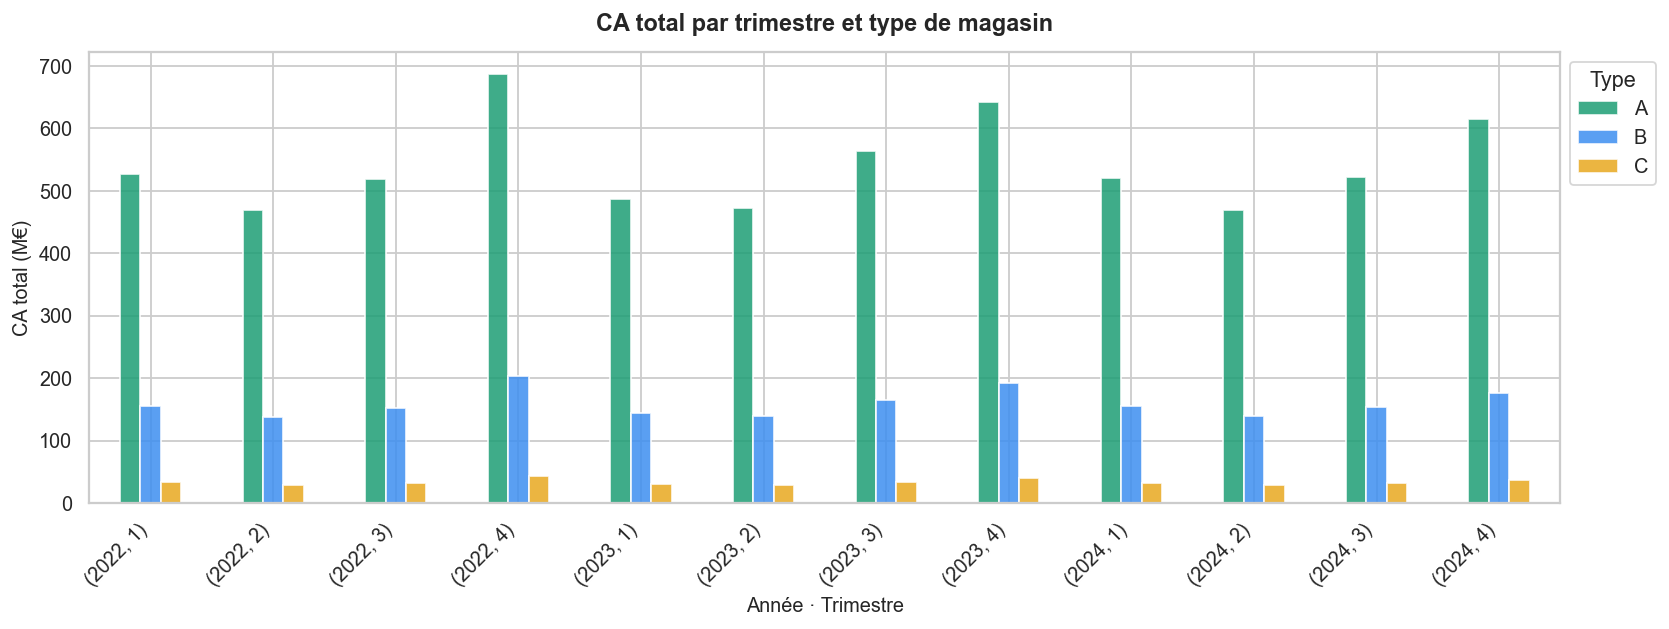

In [45]:
# ── 1B. CA par trimestre × type ───────────────────────────
q1b = """
SELECT
    d.year,
    d.quarter,
    s.storetype,
    ROUND(SUM(f."weeklysalesclean")::numeric, 0)  AS ca_total,
    ROUND(AVG(f."weeklysalesclean")::numeric, 2)  AS ca_moyen,
    COUNT(DISTINCT f."storeid")                    AS nb_stores
FROM "factsales" f
JOIN "dimdate"  d ON f."date"     = d."date"
JOIN "dimstore" s ON f."storeid" = s."storeid"
GROUP BY d."year", d."quarter", s.storetype
ORDER BY d."year", d."quarter", s.storetype
"""
df_quarter = sql(q1b)
print("── 1B · CA par Trimestre × Type ────────────────────────")
display(df_quarter.head(12))
df_quarter.to_csv(os.path.join(TABLES, "sql_ca_trimestre_type.csv"), index=False)

# Visualisation (Le reste du code Python demeure inchangé)
pivot_q = (
    df_quarter.pivot_table(
        values="ca_total",
        index=["year", "quarter"],
        columns="storetype",
        aggfunc="sum",
    )
    / 1e6
)
pivot_q.plot(
    kind="bar",
    figsize=(13, 5),
    color=[COLOR_A, COLOR_B, COLOR_C],
    edgecolor="white",
    alpha=0.85,
)
plt.title("CA total par trimestre et type de magasin")
plt.ylabel("CA total (M€)")
plt.xlabel("Année · Trimestre")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Type", bbox_to_anchor=(1, 1))
plt.tight_layout()
save_fig("12_ca_trimestre_type.png")
plt.show()

---
## CASE WHEN — Segmentation promotionnelle

2 · Segmentation promotionnelle (CASE WHEN)


,segment_promo,storetype,nb_obs,ca_moyen,ca_total,markdown_moyen,vs_moyenne
0,1 · Promo faible,A,2160,75190.67,1.624119e+08,4227.67,Au-dessus moyenne
1,1 · Promo faible,B,1360,36967.19,5.027538e+07,4217.05,En-dessous moyenne
2,1 · Promo faible,C,620,15769.65,9.777181e+06,4214.49,En-dessous moyenne
3,2 · Promo modérée,A,73260,77050.74,5.644737e+09,10542.31,Au-dessus moyenne
4,2 · Promo modérée,B,44980,36988.21,1.663729e+09,10443.83,En-dessous moyenne
5,2 · Promo modérée,C,22340,15529.43,3.469275e+08,10385.99,En-dessous moyenne
6,3 · Promo forte,A,5700,120677.84,6.878637e+08,24935.30,Au-dessus moyenne
7,3 · Promo forte,B,3580,56034.80,2.006046e+08,25376.50,En-dessous moyenne
8,3 · Promo forte,C,2000,24108.70,4.821741e+07,25327.92,En-dessous moyenne


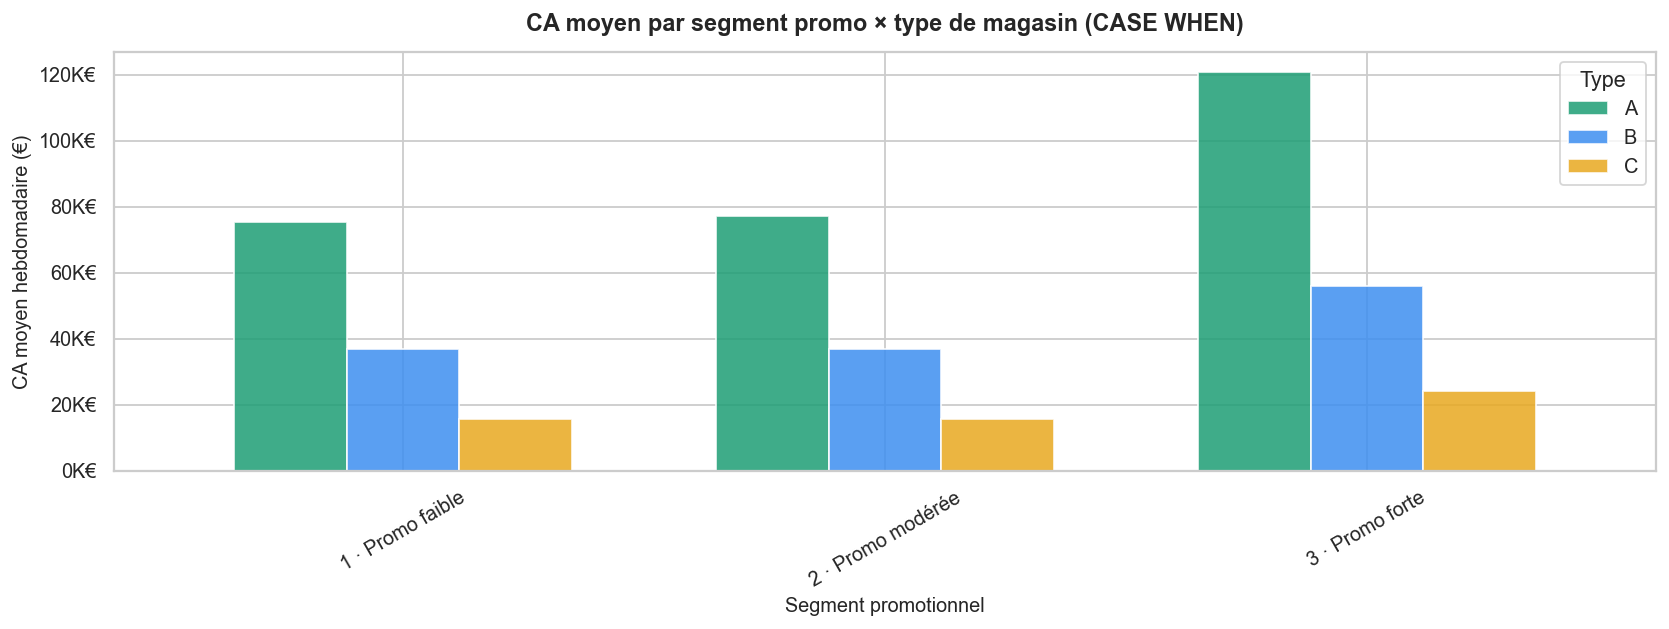

 Exporté → sql_segmentation_promo.csv


In [46]:
q2 = """
SELECT
    CASE
        WHEN m.totalmarkdown IS NULL
          OR m.totalmarkdown = 0          THEN '0 · Aucune promo'
        WHEN m.totalmarkdown < 5000       THEN '1 · Promo faible'
        WHEN m.totalmarkdown < 20000      THEN '2 · Promo modérée'
        WHEN m.totalmarkdown < 50000      THEN '3 · Promo forte'
        ELSE                                   '4 · Promo très forte'
    END AS segment_promo,
    s.storetype,                           
    COUNT(*)                                AS nb_obs,
    ROUND(AVG(f.weeklysalesclean)::numeric, 2) AS ca_moyen,
    ROUND(SUM(f.weeklysalesclean)::numeric, 0) AS ca_total,
    ROUND(AVG(m.totalmarkdown)::numeric, 2)    AS markdown_moyen,
    CASE
        WHEN AVG(f.weeklysalesclean) > (
            SELECT AVG(weeklysalesclean) FROM factsales
        ) THEN 'Au-dessus moyenne'
        ELSE 'En-dessous moyenne'
    END AS vs_moyenne
FROM factsales f
JOIN dimstore s ON f.storeid = s.storeid
LEFT JOIN dimmarkdown m ON f.storeid = m.storeid AND f.date = m.date
GROUP BY 
    CASE
        WHEN m.totalmarkdown IS NULL
          OR m.totalmarkdown = 0   THEN '0 · Aucune promo'
        WHEN m.totalmarkdown < 5000  THEN '1 · Promo faible'
        WHEN m.totalmarkdown < 20000 THEN '2 · Promo modérée'
        WHEN m.totalmarkdown < 50000 THEN '3 · Promo forte'
        ELSE                                   '4 · Promo très forte'
    END,
    s.storetype                          
ORDER BY segment_promo, s.storetype;
"""
df_promo_seg = sql(q2)
print("2 · Segmentation promotionnelle (CASE WHEN)")
display(df_promo_seg)
df_promo_seg.to_csv(os.path.join(TABLES, "sql_segmentation_promo.csv"), index=False)

# Visualisation
pivot_promo = df_promo_seg.pivot_table(
    values="ca_moyen", index="segment_promo", columns="storetype"
)
fig, ax = plt.subplots(figsize=(13, 5))
pivot_promo.plot(
    kind="bar",
    ax=ax,
    color=[COLOR_A, COLOR_B, COLOR_C],
    edgecolor="white",
    alpha=0.85,
    width=0.7,
)
ax.set_title("CA moyen par segment promo × type de magasin (CASE WHEN)")
ax.set_ylabel("CA moyen hebdomadaire (€)")
ax.set_xlabel("Segment promotionnel")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{int(y / 1000)}K€"))
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Type", bbox_to_anchor=(1, 1))
plt.tight_layout()
save_fig("13_segmentation_promo_case_when.png")
plt.show()
print(" Exporté → sql_segmentation_promo.csv")

---
## REGEXP — Filtrage et nettoyage des labels

In [47]:
# ── 3A. Stores dont le label correspond au pattern Store_XX ──
q3a = """
SELECT
    "storeid",
    "storelabel",
    "storetype",
    "storesize",
    "sizecategory",
    CASE
        WHEN "storelabel" ~ '^Store_[0-9]{2}$' THEN 'Format valide'
        ELSE 'Format invalide'
    END AS label_status
FROM "dimstore"
ORDER BY "storeid";
"""
df_regex_store = sql(q3a)
print("3A · Validation labels stores (REGEXP)")
print(
    f"   Formats valides   : {(df_regex_store['label_status'] == 'Format valide').sum()}"
)
print(
    f"   Formats invalides : {(df_regex_store['label_status'] == 'Format invalide').sum()}"
)
display(df_regex_store.head(10))

3A · Validation labels stores (REGEXP)
   Formats valides   : 50
   Formats invalides : 0


,storeid,storelabel,storetype,storesize,sizecategory,label_status
0,1,Store_01,A,213810,Large,Format valide
1,2,Store_02,C,31639,Small,Format valide
2,3,Store_03,B,102098,Medium,Format valide
3,4,Store_04,B,88289,Medium,Format valide
4,5,Store_05,A,218696,Large,Format valide
5,6,Store_06,A,207397,Large,Format valide
6,7,Store_07,A,134165,Medium,Format valide
7,8,Store_08,C,36140,Small,Format valide
8,9,Store_09,B,100495,Medium,Format valide
9,10,Store_10,B,143563,Medium,Format valide


In [48]:
# ── 3B. Départements à numéro pair vs impair (REGEXP) ────────
q3b = """
SELECT
    d."deptid",
    d."deptlabel",
    CASE
        WHEN CAST(d."deptid" AS TEXT) ~ '^[0-9]*[02468]$' -- Utilisation de ~ au lieu de REGEXP
        THEN 'Numéro pair'
        ELSE 'Numéro impair'
    END AS dept_parite,
    ROUND(SUM(f."weeklysalesclean")::numeric, 0)  AS ca_total, -- Ajout de ::numeric
    ROUND(AVG(f."weeklysalesclean")::numeric, 2)  AS ca_moyen  -- Ajout de ::numeric
FROM "dimdept" d
JOIN "factsales" f ON d."deptid" = f."deptid"
GROUP BY d."deptid", d."deptlabel" -- Ajout obligatoire de deptlabel dans le GROUP BY
ORDER BY ca_total DESC
"""
df_regex_dept = sql(q3b)

# Synthèse pair vs impair
parite_stats = (
    df_regex_dept.groupby("dept_parite")
    .agg(
        nb_depts=("deptid", "count"),
        ca_total=("ca_total", "sum"),
        ca_moyen=("ca_moyen", "mean"),
    )
    .reset_index()
)
print(" 3B · Depts pair vs impair (REGEXP)")
display(parite_stats)
display(df_regex_dept.head(10))

 3B · Depts pair vs impair (REGEXP)


,dept_parite,nb_depts,ca_total,ca_moyen
0,Numéro impair,10,4.317828e+09,55356.775
1,Numéro pair,10,4.496716e+09,57650.205


,deptid,deptlabel,dept_parite,ca_total,ca_moyen
0,20,Dept_20,Numéro pair,592303555.0,75936.35
1,19,Dept_19,Numéro impair,572534948.0,73401.92
2,18,Dept_18,Numéro pair,560188573.0,71819.05
3,17,Dept_17,Numéro impair,539800381.0,69205.18
4,16,Dept_16,Numéro pair,529686011.0,67908.46
5,15,Dept_15,Numéro impair,508925177.0,65246.82
6,14,Dept_14,Numéro pair,491760185.0,63046.18
7,13,Dept_13,Numéro impair,474922756.0,60887.53
8,12,Dept_12,Numéro pair,467190571.0,59896.23
9,11,Dept_11,Numéro impair,454113550.0,58219.69


In [49]:
# ── 3C. Filtrer les dates de fin d'année (décembre) via REGEXP ─
q3c = """
SELECT
    f."date",                         
    f."storeid",
    ROUND(SUM(f."weeklysalesclean")::numeric, 0) AS ca_total, -- Ajout de ::numeric
    COUNT(DISTINCT f."deptid") AS nb_depts
FROM "factsales" f
WHERE CAST(f."date" AS TEXT) ~ '-12-'  
GROUP BY f."date", f."storeid"
ORDER BY f."date", ca_total DESC
"""
df_regex_dec = sql(q3c)
print(" 3C · Semaines de décembre filtrées par REGEXP")
print(f"   {len(df_regex_dec):,} observations en décembre")
print(f"   CA moyen/sem décembre : {df_regex_dec['ca_total'].mean():,.0f}€")
display(df_regex_dec.head(5))


df_regex_dec.to_csv(os.path.join(TABLES, "sql_regex_decembre.csv"), index=False)
print(" Exporté → sql_regex_decembre.csv")

 3C · Semaines de décembre filtrées par REGEXP
   650 observations en décembre
   CA moyen/sem décembre : 1,418,332€


,date,storeid,ca_total,nb_depts
0,2022-12-03,6,2182567.0,20
1,2022-12-03,1,2160655.0,20
2,2022-12-03,37,2123698.0,20
3,2022-12-03,47,1948253.0,20
4,2022-12-03,38,1882501.0,20


 Exporté → sql_regex_decembre.csv


---
## RANK / DENSE_RANK — Classement des stores

4 · RANK / DENSE_RANK des stores


,storeid,storelabel,storetype,sizecategory,ca_total,ca_moyen,rang_global,rang_dense,rang_dans_type,pct_ca_total
0,32,Store_32,A,Large,303223049.0,97186.87,1,1,1,3.44
1,41,Store_41,A,Large,301811851.0,96734.57,2,2,2,3.42
2,5,Store_05,A,Large,300063877.0,96174.32,3,3,3,3.40
3,1,Store_01,A,Large,299904996.0,96123.40,4,4,4,3.40
4,11,Store_11,A,Large,292354025.0,93703.21,5,5,5,3.32
5,37,Store_37,A,Large,291374339.0,93389.21,6,6,6,3.31
6,6,Store_06,A,Large,290117939.0,92986.52,7,7,7,3.29
7,47,Store_47,A,Large,285766679.0,91591.88,8,8,8,3.24
8,38,Store_38,A,Large,280749382.0,89983.78,9,9,9,3.19
9,23,Store_23,A,Large,279639037.0,89627.90,10,10,10,3.17


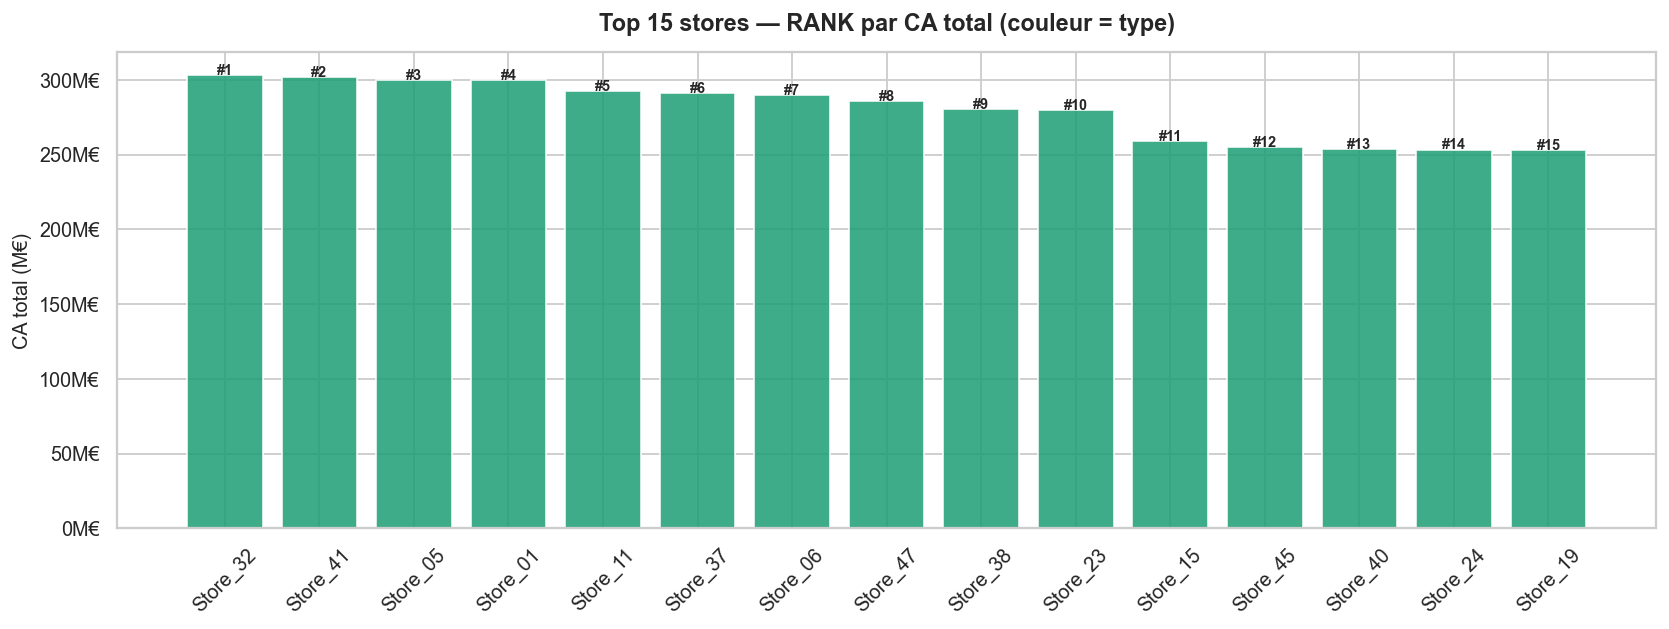

 Exporté → sql_ranking_stores.csv


In [50]:
q4 = """
WITH store_ca AS (
    SELECT
        f.storeid,
        s.storelabel,       
        s.storetype,
        s.sizecategory,
        ROUND(SUM(f.weeklysalesclean)::numeric, 0)  AS ca_total,
        ROUND(AVG(f.weeklysalesclean)::numeric, 2)  AS ca_moyen
    FROM factsales f
    JOIN dimstore s ON f.storeid = s.storeid
    GROUP BY f.storeid, s.storelabel, s.storetype, s.sizecategory -- Correction ici
)
SELECT
    storeid,
    storelabel,
    storetype,
    sizecategory,
    ca_total,
    ca_moyen,
    RANK()       OVER (ORDER BY ca_total DESC)              AS rang_global,
    DENSE_RANK() OVER (ORDER BY ca_total DESC)              AS rang_dense,
    RANK()       OVER (PARTITION BY storetype
                       ORDER BY ca_total DESC)              AS rang_dans_type,
    ROUND((ca_total * 100.0 / SUM(ca_total) OVER ( ))::numeric, 2) AS pct_ca_total
FROM store_ca
ORDER BY rang_global;
"""
df_rank = sql(q4)
print("4 · RANK / DENSE_RANK des stores")
display(df_rank.head(15))
df_rank.to_csv(os.path.join(TABLES, "sql_ranking_stores.csv"), index=False)

# Visualisation top 15
top15 = df_rank.head(15)
colors = [
    {"A": COLOR_A, "B": COLOR_B, "C": COLOR_C}.get(t, COLOR_B)
    for t in top15["storetype"]
]
fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(
    top15["storelabel"],
    top15["ca_total"] / 1e6,
    color=colors,
    alpha=0.85,
    edgecolor="white",
)
for bar, row in zip(bars, top15.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"#{row.rang_global}",
        ha="center",
        fontsize=8,
        fontweight="bold",
    )
ax.set_title("Top 15 stores — RANK par CA total (couleur = type)")
ax.set_ylabel("CA total (M€)")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.0f}M€"))
plt.tight_layout()
save_fig("14_ranking_stores.png")
plt.show()
print(" Exporté → sql_ranking_stores.csv")

---
## Vue consolidée — Jointure complète schéma étoile

In [51]:
q9 = """
SELECT
    f.storeid,
    s.storelabel,
    s.storetype                              AS store_type,
    s.storesize,
    s.sizecategory,
    f.deptid,
    dp.deptlabel,
    f.date,
    d.year,
    d.quarter,
    d.month,
    d.monthname,
    d.week,
    d.isholiday,
    d.holidaylabel,
    f.weeklysalesclean                AS ca_semaine,
    COALESCE(m.totalmarkdown, 0)       AS total_markdown,
    COALESCE(m.hasmarkdown,   0)       AS has_markdown,
    COALESCE(m.markdown1,      0)       AS markdown1,
    COALESCE(m.markdown2,      0)       AS markdown2,
    COALESCE(m.markdown3,      0)       AS markdown3,
    COALESCE(m.markdown4,      0)       AS markdown4,
    COALESCE(m.markdown5,      0)       AS markdown5
FROM factsales f
JOIN dimstore    s  ON f.storeid = s.storeid
JOIN dimdate     d  ON f.date     = d.date
JOIN dimdept     dp ON f.deptid  = dp.deptid
LEFT JOIN dimmarkdown m ON f.storeid = m.storeid AND f.date = m.date
ORDER BY f.storeid, f.date, f.deptid
"""
df_vue = sql(q9)
print("9 · Vue consolidée — jointure complète étoile")
print(f"   {len(df_vue):,} lignes × {df_vue.shape[1]} colonnes")
display(df_vue.head(5))

# Export pour Power BI
df_vue.to_csv(os.path.join(TABLES, "sql_vue_consolidee.csv"), index=False)
print(" Exporté → sql_vue_consolidee.csv  (table principale Power BI)")

9 · Vue consolidée — jointure complète étoile
   156,000 lignes × 23 colonnes


,storeid,storelabel,store_type,storesize,sizecategory,deptid,deptlabel,date,year,quarter,...,isholiday,holidaylabel,ca_semaine,total_markdown,has_markdown,markdown1,markdown2,markdown3,markdown4,markdown5
0,1,Store_01,A,213810,Large,1,Dept_01,2022-01-01,2022,1,...,1,Semaine fériée,119075.96,29476.38,1,10334.49,5905.86,5261.52,7098.43,876.08
1,1,Store_01,A,213810,Large,2,Dept_02,2022-01-01,2022,1,...,1,Semaine fériée,119107.85,29476.38,1,10334.49,5905.86,5261.52,7098.43,876.08
2,1,Store_01,A,213810,Large,3,Dept_03,2022-01-01,2022,1,...,1,Semaine fériée,84369.88,29476.38,1,10334.49,5905.86,5261.52,7098.43,876.08
3,1,Store_01,A,213810,Large,4,Dept_04,2022-01-01,2022,1,...,1,Semaine fériée,88445.24,29476.38,1,10334.49,5905.86,5261.52,7098.43,876.08
4,1,Store_01,A,213810,Large,5,Dept_05,2022-01-01,2022,1,...,1,Semaine fériée,65159.85,29476.38,1,10334.49,5905.86,5261.52,7098.43,876.08


 Exporté → sql_vue_consolidee.csv  (table principale Power BI)


---
## Export final — Tables Power BI & synthèse

In [52]:
conn.close()

# Récap des fichiers exportés
exports = [f for f in os.listdir(TABLES) if f.startswith("sql_") and f.endswith(".csv")]


print(" PARTIE 3 TERMINÉE — Analyses SQL avancées")
print(f"\n  {len(exports)} fichiers SQL exportés dans outputs/tables/ :")
for f in sorted(exports):
    size = os.path.getsize(os.path.join(TABLES, f))
    print(f"     {f:<40} {size / 1024:.1f} KB")

figs = [f for f in os.listdir(FIGURES) if f.endswith(".png")]
print(f"\n  {len(figs)} graphiques exportés dans outputs/figures/")

print()
print("   Techniques SQL utilisées :")
techniques = [
    "GROUP BY + agrégats (SUM, AVG, COUNT, MIN, MAX)",
    "WINDOW FUNCTION pct avec SUM() OVER ()",
    "CASE WHEN — segmentation promotionnelle",
    "REGEXP — validation et filtrage de labels",
    "RANK() / DENSE_RANK() OVER (PARTITION BY)",
    "CROSS JOIN — jointure avec référence globale",
    "Jointure complète 5 tables schéma étoile",
]
for t in techniques:
    print(f"     {t}")
print("\n Prochaine étape : Partie 4 — Dashboard Power BI")

 PARTIE 3 TERMINÉE — Analyses SQL avancées

  6 fichiers SQL exportés dans outputs/tables/ :
     sql_ca_trimestre_type.csv                1.2 KB
     sql_ca_type_size.csv                     0.4 KB
     sql_ranking_stores.csv                   2.7 KB
     sql_regex_decembre.csv                   16.8 KB
     sql_segmentation_promo.csv               0.7 KB
     sql_vue_consolidee.csv                   22349.3 KB

  13 graphiques exportés dans outputs/figures/

   Techniques SQL utilisées :
     GROUP BY + agrégats (SUM, AVG, COUNT, MIN, MAX)
     WINDOW FUNCTION pct avec SUM() OVER ()
     CASE WHEN — segmentation promotionnelle
     REGEXP — validation et filtrage de labels
     RANK() / DENSE_RANK() OVER (PARTITION BY)
     CROSS JOIN — jointure avec référence globale
     Jointure complète 5 tables schéma étoile

 Prochaine étape : Partie 4 — Dashboard Power BI
